# Predicting survival post alloHCT using Machine Learning

**Author:** Asif Adil  
**Date:** November 18, 2025  
**Last Modified:** June 20, 2026

## Abstract

This notebook develops and evaluates machine learning models to predict post-alloHCT survival outcomes at multiple time horizons (100 days, 1 year, 2 years, 3 years). We employ a comprehensive pipeline with feature selection, preprocessing, hyperparameter tuning via grid search, and calibrated classifiers across three model families (Logistic Regression, Gradient Boosting, Random Forest). Model performance is assessed using stratified cross-validation with metrics including AUROC, AUPRC, and calibration curves, with SHAP analysis for interpretability.


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import glob, os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# remove warnings
import warnings
warnings.filterwarnings('ignore')

from pyprojroot import here

In [3]:
# Add the project root to sys.path
sys.path.append(str(here()))

from hspc.config import get_config
config = get_config()

In [4]:
import os, warnings, math, json
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    accuracy_score, precision_score, recall_score, f1_score, balanced_accuracy_score, precision_recall_curve,
    roc_curve
)
from sklearn.calibration import calibration_curve
import joblib
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from collections import Counter


from allosurv.allosurv import ( make_preprocessor, 
                               make_models_and_grids,
                               make_labels,
                               evaluate,
                               plot_roc_pr_cal,
                               plot_shap_for_horizon,
                               plot_performance_curves,
)

In [5]:
HORIZONS = {'100d':100,'1y':365,'2y':730,'3y':1095}

In [6]:
df = pd.read_csv(here() / config.data_processed / "Aryans_Top25medications_CIBMTR_processed.csv")
df.head(5)

,record_id,pat_gender,pat_age,pat_ethnicity,vital_status,survival_days,disease_category,transplant_age,stem_cell_source,donor_type,...,pantoprazole,polyethyleneglycol,potassiumchloride,prochlorperazine,promethazine,sirolimus,sulfamethoxazole-trimethoprim,tacrolimus,ursodiol,medications_missing_y
0,1,0,12,Not Hispanic or Latino (Race:Black or African ...,0,211,Severe aplastic anemia (SAA),12,MRD,A+,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0
1,2,1,37,Not Hispanic or Latino (Race:White),0,210,Acute lymphoblastic leukemia (ALL),37,MUD,O+,...,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,0
2,3,0,71,Hispanic or Latino (Race:White),0,210,Acute Myeloid Leukemia (AML),71,MUD,O+,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0
3,4,1,64,Not Hispanic or Latino (Race:White),0,208,Non-Hodgkin lymphoma (NHL),64,MUD,A+,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0
4,5,1,50,Not Hispanic or Latino (Race:White),0,204,Acute Myeloid Leukemia (AML),50,MRD,O+,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0


In [7]:
cat_cols = ['pat_gender','pat_ethnicity','disease_category','stem_cell_source','donor_type','recipient_type','conditioning_type',
            'acyclovir', 'fluconazole', 'sulfamethoxazole-trimethoprim',
       'tacrolimus', 'mycophenolatemofetil', 'ondansetron', 'sirolimus',
       'letermovir', 'prochlorperazine', 'pantoprazole', 'magnesiumoxide',
       'multivitamin/supplement', 'oxycodone', 'promethazine',
       'cholecalciferol', 'potassiumchloride', 'amlodipine', 'lorazepam',
       'melatonin', 'loperamide', 'ursodiol', 'acetaminophen', 'olanzapine',
       'polyethyleneglycol', 'gabapentin', 'Complication', 'Bacterial Infection',
       'Viral Infection', 'Fungal Infection', 'GVHD', 'Gastrointestinal',
       'Hematologic', 'Cardiac', 'Hepatobilliary', 'Neurological', 'Renal/Urinary', 'Pulmonary/Respiratory',
       'Transplant-Related', 'Vascular', 'Other', 'complication_missing', 'medications_missing']

In [8]:
# ==== Simple feature selection ====
# Keep obvious structured columns: numeric + short categorical
num_candidates = [c for c in df.columns if any(k in c.lower() for k in ['age','dose','pre','anc','wbc','rbc','plt','hgb','mcv', 'hla_match', 'CMV(recipient)'])]
# add explicitly if present
for c in ['pat_age','transplant_age','cd34_dose','tbi_dose_max','rbc_pre','wbc_pre','plt_pre','hgb_pre','anc_pre','mcv_pre', 'KPS']:
    if c in df.columns and c not in num_candidates: num_candidates.append(c)

cat_candidates = [c for c in cat_cols if c in df.columns]
# cat_candidates = [c for c in ['pat_gender','pat_ethnicity','disease_category','stem_cell_source','donor_type', 'hla_matching','recipient_type','conditioning_type'] if c in df.columns]

feature_cols = sorted(set(num_candidates + cat_candidates))
# remove rbc_mo1.1  and pat_age from the features because it is redundant with rbc_pre
if 'rbc_mo1.1' in feature_cols:
    feature_cols.remove('rbc_mo1.1')
if 'pat_age' in feature_cols:
    feature_cols.remove('pat_age')
X = df[feature_cols].copy()
print('Using', len(feature_cols), 'features')

Using 83 features


In [9]:
feature_cols

['Bacterial Infection',
 'Cardiac',
 'Fungal Infection',
 'GVHD',
 'Gastrointestinal',
 'Hematologic',
 'KPS',
 'Neurological',
 'Other',
 'Transplant-Related',
 'Vascular',
 'Viral Infection',
 'acetaminophen',
 'acyclovir',
 'amlodipine',
 'anc_mo1',
 'anc_mo2',
 'anc_mo3',
 'cd34_dose',
 'cholecalciferol',
 'complication_missing',
 'conditioning_type',
 'disease_category',
 'donor_type',
 'fluconazole',
 'gabapentin',
 'hgb_mo1',
 'hgb_mo2',
 'hgb_mo3',
 'hgb_pre',
 'hgb_week1',
 'hgb_week2',
 'hla_match_percent',
 'letermovir',
 'loperamide',
 'lorazepam',
 'magnesiumoxide',
 'mcv_mo1',
 'mcv_mo2',
 'mcv_mo3',
 'mcv_pre',
 'mcv_week1',
 'mcv_week2',
 'melatonin',
 'multivitamin/supplement',
 'mycophenolatemofetil',
 'neutrophil_pre',
 'olanzapine',
 'ondansetron',
 'oxycodone',
 'pantoprazole',
 'pat_ethnicity',
 'pat_gender',
 'plt_mo1',
 'plt_mo2',
 'plt_mo3',
 'plt_pre',
 'plt_week1',
 'plt_week2',
 'polyethyleneglycol',
 'potassiumchloride',
 'prochlorperazine',
 'promethazine'

In [10]:
all_results = []
best_models = {}
best_model_performances = {}
# create a datastructure whcich we can later utilize for plotting all the roc, prcurve, and calibration plots of each horizon in one single plot respectively
all_metrics = {}

for hname, T in HORIZONS.items():
    print(f'\n=== Horizon {hname} (T={T}) ===')
    y = make_labels(df, T)
    m = ~y.isna()
    Xh, yh = X[m], y[m].astype(int)

    pre = make_preprocessor(Xh)
    models, grids = make_models_and_grids()
    outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    fold_metrics = []
    y_all_prob, y_all_true = [], []

    for k, (tr, te) in enumerate(outer.split(Xh, yh), start=1):
        Xtr, Xte = Xh.iloc[tr], Xh.iloc[te]
        ytr, yte = yh.iloc[tr], yh.iloc[te]

        best_auc, best_model = -np.inf, None
        for mname, clf in models.items():
            pipe = Pipeline([('prep', pre), ('clf', clf)])
            gs = GridSearchCV(pipe, grids[mname], scoring='roc_auc', cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42), n_jobs=-1, refit=True)
            gs.fit(Xtr, ytr)
            cal = CalibratedClassifierCV(gs.best_estimator_, cv=3, method='isotonic')
            cal.fit(Xtr, ytr)
            yprob = cal.predict_proba(Xte)[:,1]
            auc = roc_auc_score(yte, yprob)
            if auc > best_auc:
                best_auc, best_model = auc, cal

        yprob = best_model.predict_proba(Xte)[:,1]
        ypred = (yprob>=0.5).astype(int)
        metr = evaluate(yte, yprob, ypred); metr['Fold']=k; fold_metrics.append(metr)
        y_all_prob.extend(yprob.tolist()); y_all_true.extend(yte.tolist())

    res = pd.DataFrame(fold_metrics).mean(numeric_only=True)
    print('Mean metrics over 5 folds:\n', res[['AUROC','AUPRC','Brier','Accuracy','Precision','Recall','F1','BalancedAcc']])

    # Refit best family on all labeled data
    # Pick family by higher mean AUROC from the two models trained on full data with CV
    fam_scores = {}
    for mname, clf in models.items():
        pipe = Pipeline([('prep', pre), ('clf', clf)])
        gs = GridSearchCV(pipe, grids[mname], scoring='roc_auc', cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42), n_jobs=-1, refit=True)
        gs.fit(Xh, yh)
        fam_scores[mname] = gs.best_score_
    best_family = max(fam_scores, key=fam_scores.get)
    gs = GridSearchCV(Pipeline([('prep', pre), ('clf', models[best_family])]), grids[best_family], scoring='roc_auc', cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42), n_jobs=-1, refit=True)
    gs.fit(Xh, yh)
    cal_full = CalibratedClassifierCV(gs.best_estimator_, cv=3, method='isotonic')
    cal_full.fit(Xh, yh)
    
    # for each best model, store its performance metrics like AUROC, AUPRC, etc. to plot later
    best_model_performances[hname] = evaluate(np.array(y_all_true), np.array(y_all_prob), (np.array(y_all_prob)>=0.5).astype(int))
    performance_df = pd.DataFrame.from_dict(best_model_performances, orient='index')
    # print(f'\nBest model performances for horizon {hname}:\n', performance_df)
    

    joblib.dump(cal_full, f'outputs/new/best_model_{hname}.joblib')
    best_models[hname] = f'outputs/new/best_model_{hname}.joblib'

    # plot_roc_pr_cal(np.array(y_all_true), np.array(y_all_prob), f'{hname} ({best_family})')
    
    # for each horizon, plot roc in a single figure
    all_results.append( (hname, np.array(y_all_true), np.array(y_all_prob)) )



=== Horizon 100d (T=100) ===
Mean metrics over 5 folds:
 AUROC          0.967279
AUPRC          0.896363
Brier          0.016516
Accuracy       0.982000
Precision      0.924206
Recall         0.861111
F1             0.890719
BalancedAcc    0.927271
dtype: float64

=== Horizon 1y (T=365) ===
Mean metrics over 5 folds:
 AUROC          0.807208
AUPRC          0.682261
Brier          0.124018
Accuracy       0.847826
Precision      0.835798
Recall         0.445455
F1             0.572152
BalancedAcc    0.709870
dtype: float64

=== Horizon 2y (T=730) ===
Mean metrics over 5 folds:
 AUROC          0.774723
AUPRC          0.720607
Brier          0.181489
Accuracy       0.713437
Precision      0.682103
Recall         0.496552
F1             0.568812
BalancedAcc    0.671703
dtype: float64

=== Horizon 3y (T=1095) ===
Mean metrics over 5 folds:
 AUROC          0.819951
AUPRC          0.832077
Brier          0.178212
Accuracy       0.724604
Precision      0.732402
Recall         0.704813
F1      

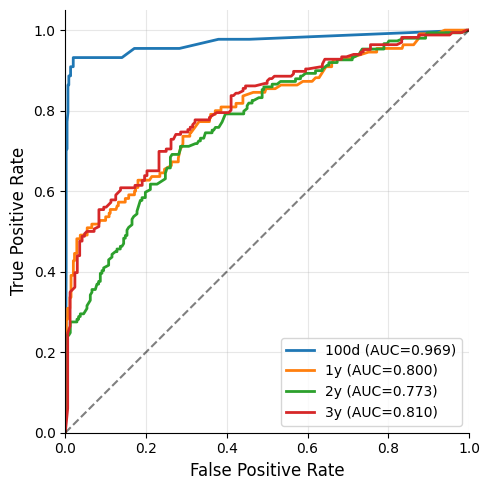

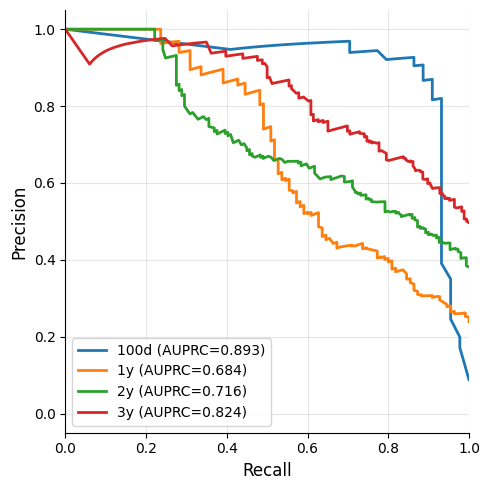

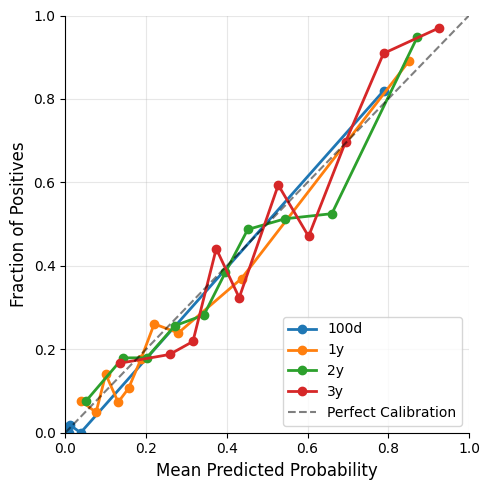

In [11]:
plot_data = [(y_true, y_prob, hname) for hname, y_true, y_prob in all_results]

# Combined subplots (original behavior)
# plot_performance_curves(plot_data)

# Separate plots  
plot_performance_curves(plot_data, figsize=(5, 5), separate_plots=True, show_full_curves=True, save_prefix='outputs/new/performance_', filetype='pdf')


Loading model for 100D horizon...
Transforming features...
Creating SHAP explainer for GradientBoostingClassifier...
Computing SHAP values...
Using raw SHAP values
Plot saved to: outputs/new/shap_100d.tiff


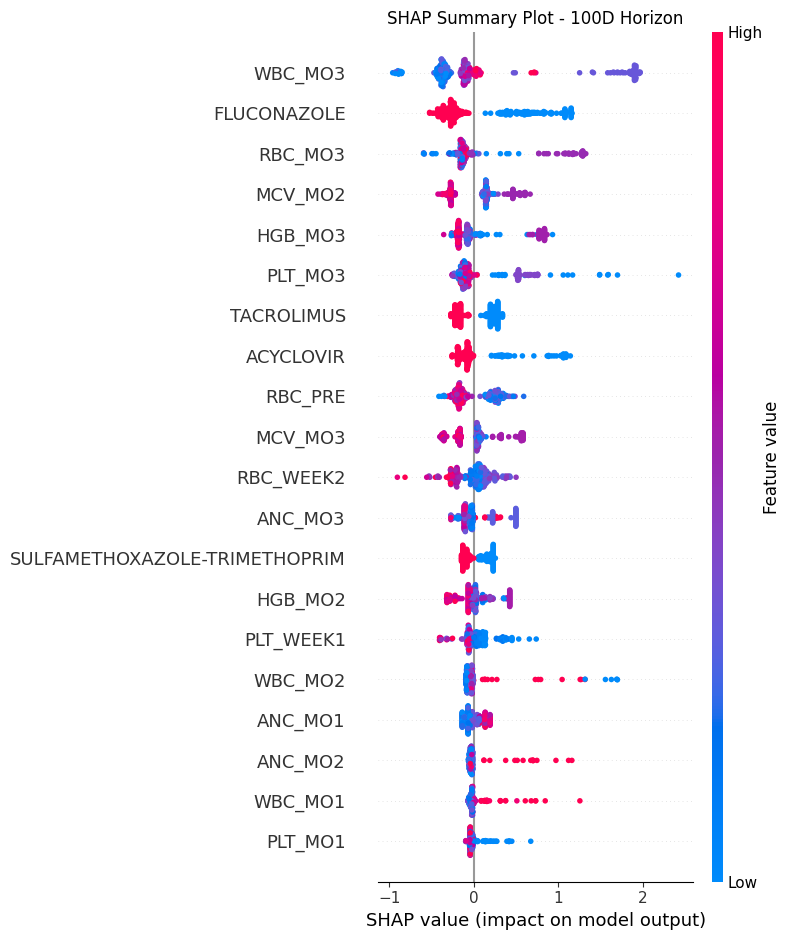

✓ SHAP analysis complete for 100D horizon
  Model type: GradientBoostingClassifier
Loading model for 1Y horizon...
Transforming features...
Creating SHAP explainer for GradientBoostingClassifier...
Computing SHAP values...
Using raw SHAP values
Plot saved to: outputs/new/shap_1y.tiff


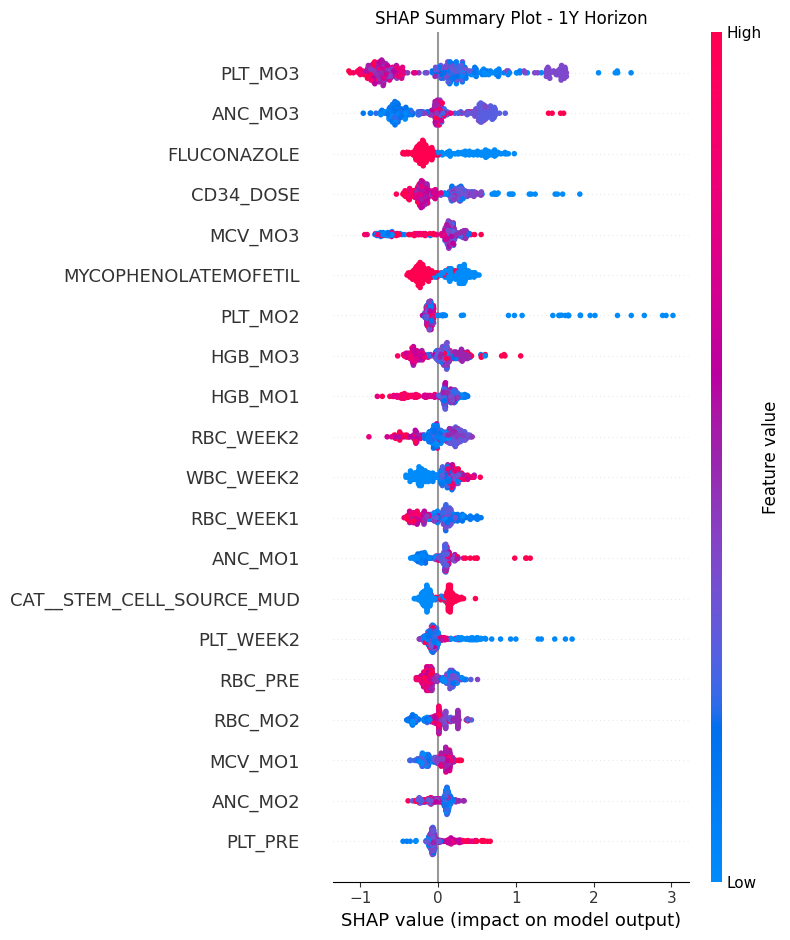

✓ SHAP analysis complete for 1Y horizon
  Model type: GradientBoostingClassifier
Loading model for 2Y horizon...
Transforming features...
Creating SHAP explainer for RandomForestClassifier...
Computing SHAP values...
Using SHAP values for positive class (class 1)
Plot saved to: outputs/new/shap_2y.tiff


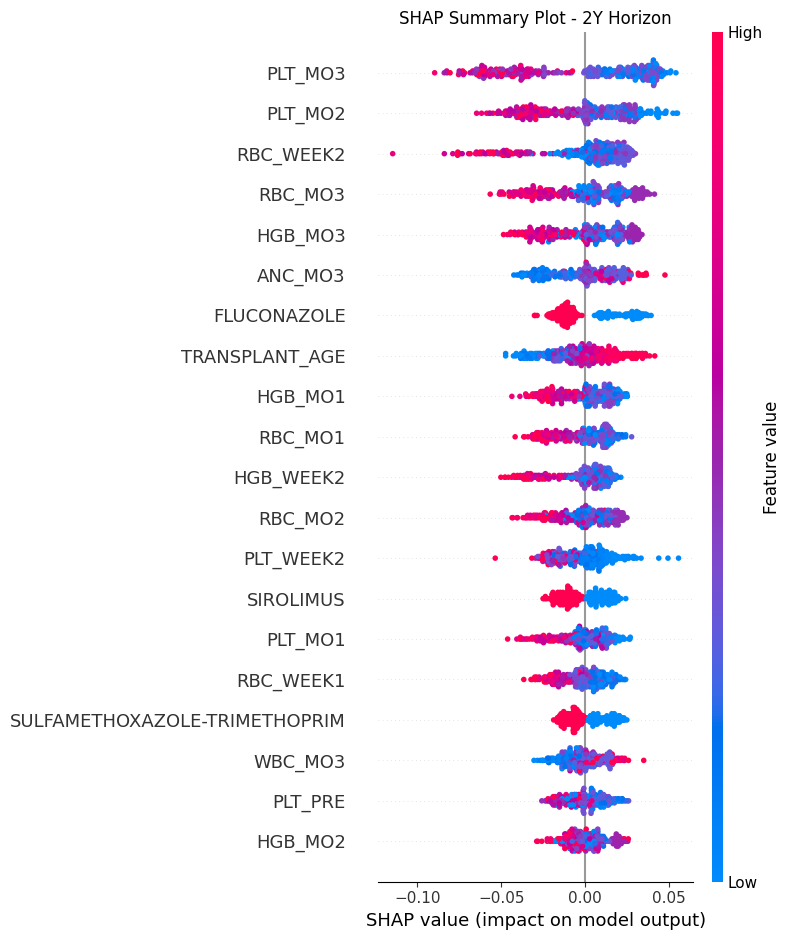

✓ SHAP analysis complete for 2Y horizon
  Model type: RandomForestClassifier
Loading model for 3Y horizon...
Transforming features...
Creating SHAP explainer for RandomForestClassifier...
Computing SHAP values...
Using SHAP values for positive class (class 1)
Plot saved to: outputs/new/shap_3y.tiff


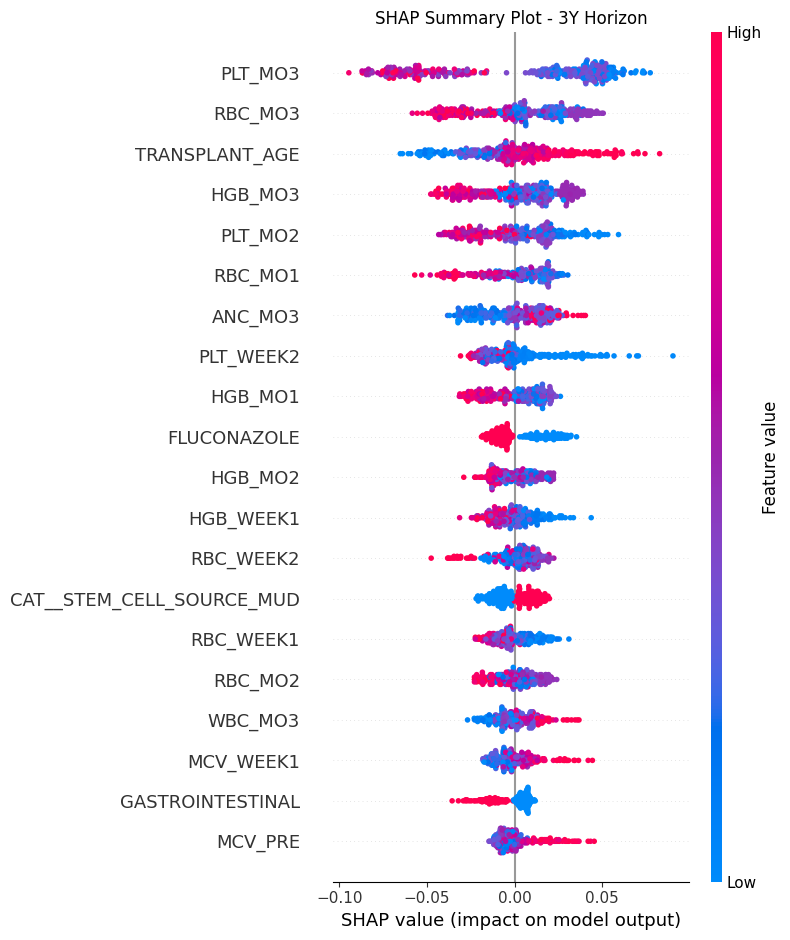

✓ SHAP analysis complete for 3Y horizon
  Model type: RandomForestClassifier


In [12]:
from allosurv.allosurv import plot_shap_for_horizon
# plot_shap_all_horizons

# Basic usage
# plot_shap_for_horizon(best_models, '3y', Xh)

# All horizons with bar charts
# plot_shap_all_horizons(best_models, Xh, plot_type='bar', max_display=15)

# Save individual plots
for horizon in ['100d', '1y', '2y', '3y']:
    plot_shap_for_horizon(best_models, horizon, Xh, save=True, filetype='tiff', save_prefix=f'outputs/new/shap_{horizon}'
                         )

In [13]:
performance_df

,AUROC,AUPRC,Brier,Accuracy,Precision,Recall,F1,BalancedAcc
100d,0.969473,0.893297,0.016516,0.982000,0.926829,0.863636,0.894118,0.928529
1y,0.799597,0.684072,0.124018,0.847826,0.844828,0.445455,0.583333,0.709870
2y,0.772866,0.715603,0.181452,0.713555,0.666667,0.496644,0.569231,0.671876
3y,0.809990,0.824280,0.178223,0.724551,0.731250,0.704819,0.717791,0.724433


In [14]:
best_models

{'100d': 'outputs/new/best_model_100d.joblib',
 '1y': 'outputs/new/best_model_1y.joblib',
 '2y': 'outputs/new/best_model_2y.joblib',
 '3y': 'outputs/new/best_model_3y.joblib'}

In [15]:
# save performance_df to csv
performance_df.to_csv('outputs/new/best_model_performances.csv')

In [16]:
for hname, model_path in best_models.items():
    model = joblib.load(model_path)
    clf = model.estimator.named_steps['clf']
    alg_name = clf.__class__.__name__
    print(f'Best model for horizon {hname}: {alg_name}')

Best model for horizon 100d: GradientBoostingClassifier
Best model for horizon 1y: GradientBoostingClassifier
Best model for horizon 2y: RandomForestClassifier
Best model for horizon 3y: RandomForestClassifier


In [17]:
# round off performance metrics to 3 decimal places
performance_df = performance_df.round(3)
performance_df

,AUROC,AUPRC,Brier,Accuracy,Precision,Recall,F1,BalancedAcc
100d,0.969,0.893,0.017,0.982,0.927,0.864,0.894,0.929
1y,0.800,0.684,0.124,0.848,0.845,0.445,0.583,0.710
2y,0.773,0.716,0.181,0.714,0.667,0.497,0.569,0.672
3y,0.810,0.824,0.178,0.725,0.731,0.705,0.718,0.724
